# Dynamic Genetic Algorithm Notebook

This notebook runs one of two original genetic algorithm examples based on the last digit of the ID you enter:
- even last digit: binary GA with a custom concave fitness function, tables, and a plot
- odd last digit: string-matching GA with custom population settings and mating probabilities

In [45]:
import random
from dataclasses import dataclass
from typing import List, Sequence, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [46]:
# --- Even (binary) GA: decoding + fitness + plotting ---
def bits_to_int(bits: Sequence[int]) -> int:
    return int(''.join(str(b) for b in bits), 2)

def decode_gene_to_x(g: int, x_min: float, x_max: float, max_g: int) -> float:
    return x_min + (x_max - x_min) * (g / max_g)

def concave_fitness(x: float) -> float:
    # Concave (downward) parabola
    return 12.0 - (x - 2.1) ** 2

def nonnegative_fitness(x: float) -> float:
    # Roulette selection needs nonnegative weights
    return max(0.0, concave_fitness(x))

def plot_fitness(x_min: float, x_max: float) -> None:
    xs = np.linspace(x_min, x_max, 500)
    ys = np.array([concave_fitness(float(x)) for x in xs])

    y_min = float(np.min(ys))
    y_max = float(np.max(ys))
    y_pad = max(1.5, 0.12 * (y_max - y_min))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(xs, ys, color='blue', linewidth=2.5)

    # Textbook-style axes that cross at the origin
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(1.4)
    ax.spines['bottom'].set_linewidth(1.4)

    ax.set_xlim(x_min - 1, x_max + 1)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    x_ticks = np.arange(np.floor(x_min), np.ceil(x_max) + 1, 1)
    y_ticks = np.arange(np.floor(y_min - y_pad), np.ceil(y_max + y_pad) + 1, 1)
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    ax.grid(True, which='major', color='#cfcfcf', linewidth=0.9)

    # Add arrowheads and labels to resemble the textbook figure.
    x_left, x_right = ax.get_xlim()
    y_bottom, y_top = ax.get_ylim()
    ax.annotate('', xy=(x_right, 0), xytext=(x_left, 0),
                arrowprops=dict(arrowstyle='->', color='black', linewidth=1.4))
    ax.annotate('', xy=(0, y_top), xytext=(0, y_bottom),
                arrowprops=dict(arrowstyle='->', color='black', linewidth=1.4))

    ax.text(x_right + 0.2, -0.3, r'$x$', fontsize=18)
    ax.text(-0.9, y_top + 0.2, r'$f(x)$', fontsize=18)

    peak_index = int(np.argmax(ys))
    peak_x = float(xs[peak_index])
    peak_y = float(ys[peak_index])
    ax.scatter([peak_x], [peak_y], color='blue', s=20, zorder=3)

    ax.tick_params(axis='both', labelsize=12, length=0)
    plt.tight_layout()
    plt.show()

In [48]:
# --- Even (binary) GA: individual + initial population ---
@dataclass(frozen=True)
class BinaryIndividual:
    chromosome: Tuple[int, ...]
    x_value: float
    fitness: float

    @property
    def chrom_str(self) -> str:
        return ''.join(str(b) for b in self.chromosome)


def make_initial_population(bitstrings: Sequence[str], x_min: float, x_max: float) -> List[BinaryIndividual]:
    n_bits = len(bitstrings[0])
    max_g = (2 ** n_bits) - 1
    pop: List[BinaryIndividual] = []
    for s in bitstrings:
        bits = tuple(int(c) for c in s)
        g = bits_to_int(bits)
        x = decode_gene_to_x(g, x_min, x_max, max_g)
        fit = nonnegative_fitness(x)
        pop.append(BinaryIndividual(bits, x, fit))
    return pop

In [49]:
# --- Even (binary) GA: selection + crossover + mutation operators ---
def roulette_pick(indices: Sequence[int], weights: Sequence[float]) -> int:
    total = float(sum(weights))
    if total <= 0:
        return random.choice(list(indices))
    r = random.random() * total
    running = 0.0
    for idx, w in zip(indices, weights):
        running += float(w)
        if running >= r:
            return idx
    return indices[-1]


def single_point_crossover(a: Sequence[int], b: Sequence[int], point: int) -> Tuple[List[int], List[int]]:
    c1 = list(a[:point]) + list(b[point:])
    c2 = list(b[:point]) + list(a[point:])
    return c1, c2


def mutate_bits(bits: List[int], rate: float, force_at_least_one: bool = False) -> Tuple[List[int], int]:
    out = bits[:]
    flipped = 0
    for i in range(len(out)):
        if random.random() < rate:
            out[i] = 1 - out[i]
            flipped += 1
    if force_at_least_one and flipped == 0:
        j = random.randrange(len(out))
        out[j] = 1 - out[j]
        flipped = 1
    return out, flipped

In [50]:
# --- Even (binary) GA: Table 3.1 (initial population) ---
def build_table_3_1(pop: Sequence[BinaryIndividual]) -> pd.DataFrame:
    fitnesses = [p.fitness for p in pop]
    total = float(sum(fitnesses))
    probs = [(f / total) if total > 0 else 1.0 / len(pop) for f in fitnesses]

    df = pd.DataFrame({
        'Chromosome #': list(range(1, len(pop) + 1)),
        'Initial Population': [p.chrom_str for p in pop],
        'x value': [round(p.x_value, 4) for p in pop],
        'Fitness f(x)': [round(p.fitness, 4) for p in pop],
        'Selection Probability': [round(p, 4) for p in probs],
    })

    summary = pd.DataFrame({
        'Chromosome #': ['Sum', 'Average', 'Max'],
        'Initial Population': ['', '', ''],
        'x value': ['', '', ''],
        'Fitness f(x)': [
            round(float(sum(fitnesses)), 4),
            round(float(np.mean(fitnesses)), 4),
            round(float(np.max(fitnesses)), 4),
        ],
        'Selection Probability': [
            round(float(sum(probs)), 4),
            round(float(np.mean(probs)), 4),
            round(float(np.max(probs)), 4),
        ],
    })

    return pd.concat([df, summary], ignore_index=True)

In [52]:
# --- Even (binary) GA: Table 3.2 (mating + offspring) ---
def build_table_3_2(
    pop: Sequence[BinaryIndividual],
    x_min: float,
    x_max: float,
    mutation_rate: float,
    seed: Optional[int] = 5215,
    ) -> pd.DataFrame:
    if seed is not None:
        random.seed(seed)

    n_bits = len(pop[0].chromosome)
    max_g = (2 ** n_bits) - 1
    fitnesses = [p.fitness for p in pop]
    indices = list(range(len(pop)))

    rows = []
    total_flips = 0

    for pair_i in range(len(pop) // 2):
        i1 = roulette_pick(indices, fitnesses)
        i2 = roulette_pick(indices, fitnesses)
        while i2 == i1 and len(pop) > 1:
            i2 = roulette_pick(indices, fitnesses)

        p1 = pop[i1]
        p2 = pop[i2]
        cut = random.randint(1, n_bits - 1)
        c1, c2 = single_point_crossover(p1.chromosome, p2.chromosome, cut)

        force_first_child = (pair_i == 0)
        c1m, f1 = mutate_bits(c1, mutation_rate, force_at_least_one=force_first_child)
        c2m, f2 = mutate_bits(c2, mutation_rate, force_at_least_one=False)
        total_flips += (f1 + f2)

        pair_view = (
            ''.join(str(b) for b in p1.chromosome[:cut])
            + '|'
            + ''.join(str(b) for b in p1.chromosome[cut:])
            + '  x  '
            + ''.join(str(b) for b in p2.chromosome[:cut])
            + '|'
            + ''.join(str(b) for b in p2.chromosome[cut:])
        )

        for child_bits, child_no in [(c1m, 1), (c2m, 2)]:
            g = bits_to_int(child_bits)
            x = decode_gene_to_x(g, x_min, x_max, max_g)
            fit = nonnegative_fitness(x)
            rows.append({
                'Child #': pair_i * 2 + child_no,
                'Parents (chrom #)': f'{i1 + 1} & {i2 + 1}',
                'Mating Pairs (cut shown)': pair_view,
                'New Population': ''.join(str(b) for b in child_bits),
                'x value': round(x, 4),
                'Fitness f(x)': round(fit, 4),
            })

    df = pd.DataFrame(rows)
    summary = pd.DataFrame({
        'Child #': ['Sum', 'Average', 'Max'],
        'Parents (chrom #)': ['', '', ''],
        'Mating Pairs (cut shown)': [f'Mutations flipped (total): {total_flips}', '', ''],
        'New Population': ['', '', ''],
        'x value': ['', '', ''],
        'Fitness f(x)': [
            round(float(df['Fitness f(x)'].sum()), 4),
            round(float(df['Fitness f(x)'].mean()), 4),
            round(float(df['Fitness f(x)'].max()), 4),
        ],
    })

    return pd.concat([df, summary], ignore_index=True)

In [53]:
# --- Even (binary) GA: demo runner ---
def run_even_demo() -> None:
    x_min, x_max = -2.0, 6.0
    mutation_rate = 0.02

    # Initial population (10 chromosomes, 6 bits each)
    bitstrings = [
        '001011',
        '111000',
        '010101',
        '100110',
        '011011',
        '000111',
        '110010',
        '101001',
        '001101',
        '011100',
    ]

    plot_fitness(x_min, x_max)
    pop = make_initial_population(bitstrings, x_min, x_max)

    print('Table 3.1 style:')
    display(build_table_3_1(pop))

    print('Table 3.2 style (guaranteed >= 1 mutated bit):')
    display(build_table_3_2(pop, x_min, x_max, mutation_rate=mutation_rate, seed=5215))

In [54]:
# --- Odd (string) GA: individual + fitness + initialization ---
@dataclass(frozen=True)
class StringIndividual:
    chromosome: Tuple[str, ...]
    fitness: int

    @property
    def as_string(self) -> str:
        return ''.join(self.chromosome)


def string_fitness(chromosome: Sequence[str], target: str) -> int:
    return sum(1 for c, t in zip(chromosome, target) if c != t)


def random_string_individual(target: str, genes: str) -> StringIndividual:
    chrom = tuple(random.choice(genes) for _ in range(len(target)))
    return StringIndividual(chrom, string_fitness(chrom, target))

In [55]:
# --- Odd (string) GA: mating operator (custom probability ranges) ---
def mate_strings(
    p1: StringIndividual,
    p2: StringIndividual,
    target: str,
    genes: str,
    p_parent1: float,
    p_parent2: float,
    ) -> StringIndividual:
    # Probability ranges:
    #   r < p_parent1                         -> gene from parent1
    #   p_parent1 <= r < p_parent1+p_parent2  -> gene from parent2
    #   otherwise                             -> mutation
    child: List[str] = []
    for a, b in zip(p1.chromosome, p2.chromosome):
        r = random.random()
        if r < p_parent1:
            child.append(a)
        elif r < (p_parent1 + p_parent2):
            child.append(b)
        else:
            child.append(random.choice(genes))
    chrom = tuple(child)
    return StringIndividual(chrom, string_fitness(chrom, target))

In [56]:
# --- Odd (string) GA: demo runner (custom population, genes, probabilities, elitism) ---
def run_odd_demo() -> None:
    # ---- Custom settings (explicit per assignment prompt) ----
    POPULATION_SIZE = 120
    GENES = 'abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ 0123456789-!'
    TARGET = 'Genetic Algorithm!'

    # Probability ranges (custom): 55% from parent1, 40% from parent2, 5% mutation
    P_PARENT1 = 0.55
    P_PARENT2 = 0.40

    # Percentage of fittest individuals (elitism) (custom)
    ELITISM_PCT = 12

    # Choose parents from the top MATING_POOL_PCT% (custom)
    MATING_POOL_PCT = 45

    SEED = 5215
    MAX_GENERATIONS = 4000
    # ----------------------------------------------------------

    random.seed(SEED)
    population = [random_string_individual(TARGET, GENES) for _ in range(POPULATION_SIZE)]

    for generation in range(1, MAX_GENERATIONS + 1):
        population = sorted(population, key=lambda ind: ind.fitness)
        best = population[0]

        if generation == 1 or generation % 50 == 0 or best.fitness == 0:
            print(f'Gen {generation:4d} | best fitness={best.fitness:2d} | {best.as_string}')

        if best.fitness == 0:
            print('Target reached.')
            break

        elite_count = max(1, int(POPULATION_SIZE * (ELITISM_PCT / 100.0)))
        pool_count = max(2, int(POPULATION_SIZE * (MATING_POOL_PCT / 100.0)))

        new_generation: List[StringIndividual] = []
        new_generation.extend(population[:elite_count])

        while len(new_generation) < POPULATION_SIZE:
            parent1 = random.choice(population[:pool_count])
            parent2 = random.choice(population[:pool_count])
            child = mate_strings(parent1, parent2, TARGET, GENES, P_PARENT1, P_PARENT2)
            new_generation.append(child)

        population = new_generation

    population = sorted(population, key=lambda ind: ind.fitness)
    best = population[0]
    print(f'Final best: fitness={best.fitness} | {best.as_string}')

Last digit = 4 -> EVEN


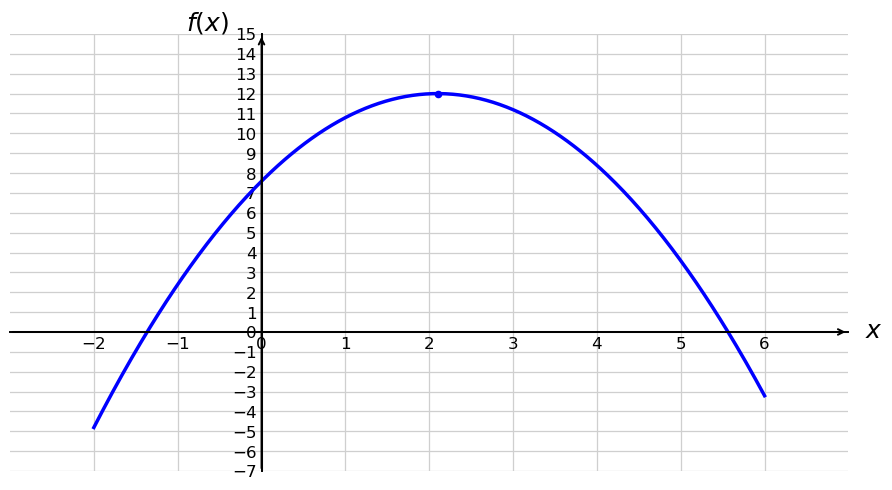

Table 3.1 style:


,Chromosome #,Initial Population,x value,Fitness f(x),Selection Probability
0,1,001011,-0.6032,4.6928,0.0604
1,2,111000,5.1111,2.9332,0.0377
2,3,010101,0.6667,9.9456,0.1280
3,4,100110,2.8254,11.4738,0.1477
4,5,011011,1.4286,11.5492,0.1486
5,6,000111,-1.1111,1.6888,0.0217
6,7,110010,4.3492,6.9411,0.0893
7,8,101001,3.2063,10.7760,0.1387
8,9,001101,-0.3492,6.0014,0.0772
9,10,011100,1.5556,11.7036,0.1506


Table 3.2 style (guaranteed >= 1 mutated bit):


,Child #,Parents (chrom #),Mating Pairs (cut shown),New Population,x value,Fitness f(x)
0,1,8 & 4,1|01001 x 1|00110,100010,2.3175,11.9527
1,2,8 & 4,1|01001 x 1|00110,101001,3.2063,10.7760
2,3,10 & 8,0111|00 x 1010|01,011101,1.6825,11.8257
3,4,10 & 8,0111|00 x 1010|01,101000,3.0794,11.0408
4,5,3 & 9,01|0101 x 00|1101,011101,1.6825,11.8257
5,6,3 & 9,01|0101 x 00|1101,000101,-1.3651,0.0000
6,7,5 & 8,0110|11 x 1010|01,011001,1.1746,11.1436
7,8,5 & 8,0110|11 x 1010|01,101011,3.4603,10.1495
8,9,3 & 5,01|0101 x 01|1011,011011,1.4286,11.5492
9,10,3 & 5,01|0101 x 01|1011,010101,0.6667,9.9456


In [57]:
def last_digit(value: str) -> int:
    digits = [c for c in value.strip() if c.isdigit()]
    if not digits:
        raise ValueError('No digits found in the provided ID.')
    return int(digits[-1])

user_id = input('Enter your ID (or any number): ').strip()
last_digit_value = last_digit(user_id)
branch_name = 'EVEN' if last_digit_value % 2 == 0 else 'ODD'
print(f'Last digit = {last_digit_value} -> {branch_name}')

if last_digit_value % 2 == 0:
    run_even_demo()
else:
    run_odd_demo()